In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [ ]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2025-03-29 02:19:02--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.008s  

2025-03-29 02:19:02 (132 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [ ]:
# let's look at the first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [ ]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [ ]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [ ]:
# let's now encode the entire text dataset and store it into a torch.Tensor
import torch
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [ ]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

In [ ]:
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

In [ ]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


In [ ]:
torch.manual_seed(1337)
batch_size = 32 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([32, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54],
        [57, 43, 60, 43, 52,  1, 63, 43],
        [60, 43, 42,  8,  0, 25, 63,  1],
        [56, 42,  5, 57,  1, 57, 39, 49],
        [43, 57, 58, 63,  6,  1, 58, 46],
        [43,  1, 51, 39, 63,  1, 40, 43],
        [58, 46, 43,  1, 43, 39, 56, 57],
        [39, 58, 47, 53, 52, 12,  1, 37],
        [53, 56, 43,  1, 21,  1, 41, 39],
        [50, 39, 52, 63,  1, 47, 58, 57],
        [56, 53, 63,  1, 42, 47, 42,  1],
        [39, 51,  1, 39, 44, 56, 39, 47],
        [17, 24, 21, 38, 13, 14, 17, 32],
        [ 1, 39, 52, 42,  1, 45, 43, 50],
        [ 1, 58, 46, 39, 58,  1, 42, 53],
        [ 1, 61, 53, 59, 50, 42,  1, 21],
        [59, 57, 40, 39, 52, 42,  1, 40],
        [52, 42,  8,  0,  0, 23, 21, 26],
        [45, 53, 42, 57,  0, 23, 43, 43],
        [52,  1, 61, 39, 57,  1, 51, 53],
      

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=2):
        super(CharLSTM, self).__init__()
        self.embed = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

In [ ]:
# Set hyperparameters
embedding_dim = 32
hidden_dim = 256
num_layers = 5
learning_rate = 0.001

model = CharLSTM(vocab_size, embedding_dim, hidden_dim, num_layers)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)



In [ ]:
def train_model(model, train_data, epochs=500):
    model.train()
    losses = []
    for epoch in range(epochs):
        hidden = (torch.zeros(num_layers, batch_size, hidden_dim),
                  torch.zeros(num_layers, batch_size, hidden_dim))
        x_batch, y_batch = get_batch('train')
        optimizer.zero_grad()
        output, hidden = model(x_batch, hidden)
        loss = criterion(output.view(-1, vocab_size), y_batch.view(-1))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
    return losses



In [ ]:
def generate_text(model, start_text, length=100, temperature=0.8):
    model.eval()
    input_seq = torch.tensor(encode(start_text), dtype=torch.long).unsqueeze(0)
    hidden = (torch.zeros(num_layers, 1, hidden_dim),
              torch.zeros(num_layers, 1, hidden_dim))
    generated_text = start_text

    for _ in range(length):
        output, hidden = model(input_seq, hidden)
        logits = output[:, -1, :] / temperature
        probs = torch.softmax(logits, dim=-1)
        next_char_idx = torch.multinomial(probs, num_samples=1).item()
        next_char = itos[next_char_idx]
        generated_text += next_char
        input_seq = torch.tensor([[next_char_idx]], dtype=torch.long)

    return generated_text



In [ ]:
losses = train_model(model, train_data)


Epoch 1, Loss: 4.1756
Epoch 2, Loss: 4.1604
Epoch 3, Loss: 4.1441
Epoch 4, Loss: 4.1343
Epoch 5, Loss: 4.0740
Epoch 6, Loss: 4.0387
Epoch 7, Loss: 3.9593
Epoch 8, Loss: 3.7974
Epoch 9, Loss: 3.7637
Epoch 10, Loss: 3.7389
Epoch 11, Loss: 3.4904
Epoch 12, Loss: 3.5204
Epoch 13, Loss: 3.4201
Epoch 14, Loss: 3.4750
Epoch 15, Loss: 3.5918
Epoch 16, Loss: 3.4703
Epoch 17, Loss: 3.4408
Epoch 18, Loss: 3.4269
Epoch 19, Loss: 3.3782
Epoch 20, Loss: 3.4659
Epoch 21, Loss: 3.3306
Epoch 22, Loss: 3.3856
Epoch 23, Loss: 3.3192
Epoch 24, Loss: 3.4223
Epoch 25, Loss: 3.4282
Epoch 26, Loss: 3.2658
Epoch 27, Loss: 3.3328
Epoch 28, Loss: 3.2858
Epoch 29, Loss: 3.4689
Epoch 30, Loss: 3.2866
Epoch 31, Loss: 3.3549
Epoch 32, Loss: 3.4056
Epoch 33, Loss: 3.2460
Epoch 34, Loss: 3.2840
Epoch 35, Loss: 3.1976
Epoch 36, Loss: 3.2348
Epoch 37, Loss: 3.3361
Epoch 38, Loss: 3.3236
Epoch 39, Loss: 3.4154
Epoch 40, Loss: 3.2718
Epoch 41, Loss: 3.2928
Epoch 42, Loss: 3.2947
Epoch 43, Loss: 3.2468
Epoch 44, Loss: 3.33

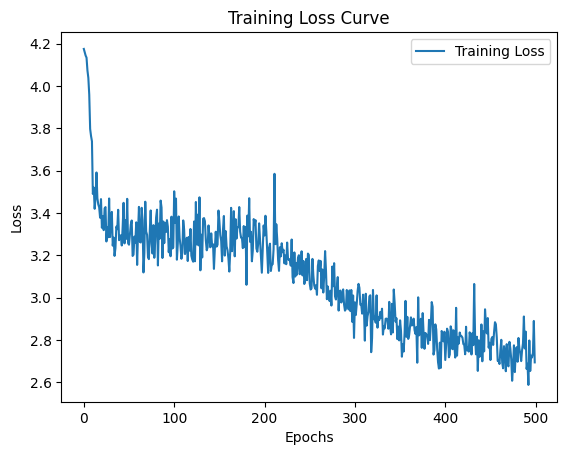

Generated Text:
 Teh: thdd
 othaeg rhmd Ceucn Nasleel yit Eobs bhlO hevtriboy moegoke:
Tn hohivcd wreen phoenoe yced b


In [ ]:
plt.plot(losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

start_text = "T"
generated_text = generate_text(model, start_text, temperature=1.0)
print("Generated Text:\n", generated_text)
